In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import copy
from scipy.stats import wilcoxon, mannwhitneyu
import pickle as pkl
import random

import nibabel as nib

import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split

from sklearn.model_selection import KFold, cross_val_score
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.feature_selection import f_regression, mutual_info_regression
from sklearn.feature_selection import RFE, SequentialFeatureSelector
from sklearn.metrics import mean_squared_error, r2_score, median_absolute_error, mean_absolute_error

from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, r2_score
from sklearn import linear_model
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from hpsklearn import HyperoptEstimator, svc

from pytorch_tabnet.tab_model import TabNetRegressor

import xgboost as xgb

from hyperopt import hp, fmin, tpe, Trials, STATUS_OK, anneal

/Users/suvodeepmajumder/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/suvodeepmajumder/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
def load_unet_result(path, _print):
    unet_df = pd.read_csv(path, index_col = 'Unnamed: 0')
    index_values = []
    for _index in unet_df.index:
        index_values.append(_index.split('-seg')[0])

    unet_df.index = index_values  
    unet_df.drop(['WT jaccard', 'TC jaccard', 'ET jaccard'], axis = 1, inplace = True)
    summary_unet_df = pd.DataFrame(zip(unet_df.mean().values.tolist(), 
                                       unet_df.std().values.tolist()), 
                                   columns = ['mean', 'std'], index = unet_df.columns)
    if _print:
        print("****UNet******")
        print(summary_unet_df)
    return summary_unet_df, unet_df

def load_nnunet_result(path, _print):
    with open(path, 'r') as file:
        data = json.load(file)

    WT = []
    TC = []
    ET = []
    file_name = []
    for case in data['metric_per_case']:
        WT.append(case['metrics']['(2, 1, 3)']['Dice'])
        TC.append(case['metrics']['(2, 3)']['Dice'])
        ET.append(case['metrics']['(3,)']['Dice'])
        file_name.append(case['reference_file'].split('/')[-1].split('.')[0])

    nnunet_df = pd.DataFrame(zip(WT, TC, ET), columns = ['WT dice', 'TC dice', 'ET dice'], 
                             index = file_name)
    summary_nnunet_df = pd.DataFrame(zip(nnunet_df.mean().values.tolist(), 
                                       nnunet_df.std().values.tolist()), 
                                   columns = ['mean', 'std'], index = nnunet_df.columns)
    if _print:
        print("****nnUNet******")
        print(summary_nnunet_df)
    return summary_nnunet_df, nnunet_df

def load_TransBTS_result(path, _print):
    with open(path, 'r') as file:
        data = json.load(file)

    WT = []
    TC = []
    ET = []
    file_name = []
    for case_id in data.keys():
        case = data[case_id]
        WT.append(case['WT'][0])
        TC.append(case['TC'][0])
        ET.append(case['ET'][0])
        file_name.append(case_id)

    TransBTS_df = pd.DataFrame(zip(WT, TC, ET), columns = ['WT dice', 'TC dice', 'ET dice'], 
                             index = file_name)
    summary_TransBTS_df = pd.DataFrame(zip(TransBTS_df.mean().values.tolist(), 
                                       TransBTS_df.std().values.tolist()), 
                                   columns = ['mean', 'std'], index = TransBTS_df.columns)
    if _print:
        print("****TransBTS******")
        print(summary_TransBTS_df)
    return summary_TransBTS_df, TransBTS_df

def read_radiomics_results(analysis_type, location):
    file_name = '../Results/Analysis_Results/Radiomics/' + location + '/' + analysis_type + '.pkl'
    with open(file_name, 'rb') as f:
        results = pkl.load(f)
    return results

def read_results(_print=True):
    path = '../Results/Result/Vanilla_Unet/Unet_test_dice.csv'
    summary_unet_df, unet_df = load_unet_result(path, _print)

    path = '../Results/Result/nnUnet/nnUNetTrainer/summary.json'
    summary_da_nnunet_df, nnunet_da_df = load_nnunet_result(path, _print)

    path = '../Results/Result/nnUnet/nnUNetTrainerNoDA/summary.json'
    summary_noda_nnunet_df, nnunet_noda_df = load_nnunet_result(path, _print)

    path = '../Results/Result/TransBTS/submission/TransBTS2023-11-03/TransBTS_summary.json'
    summary_TransBTS_df, TransBTS_df = load_TransBTS_result(path, _print)
    return unet_df, nnunet_noda_df, nnunet_da_df, TransBTS_df


def get_dataset(performance_df, analysis_types, location):
    results_df = performance_df
    for analysis_type in analysis_types:
        try:
            radiomics_results_df = read_radiomics_results(analysis_type, location)
        except Exception as e:
            print(e)
            continue
        properties = {}
        property_df = pd.DataFrame()
        for i in range(len(radiomics_results_df.keys())):
            key = list(radiomics_results_df.keys())[i]
            properties[i] = key

        for i in range(len(properties)):
            selected_property = properties[i]

            property_result_df = pd.DataFrame.from_dict(radiomics_results_df[selected_property], 
                                                        orient = 'index').astype(float)
            new_col = []
            for col in property_result_df.columns:
                new_col.append(selected_property + '_' + col + '_' + analysis_type)
            property_result_df.columns = new_col
            results_df = pd.merge(property_result_df, 
                           results_df, 
                           left_index=True, 
                           right_index=True)
#             print(property_result_df.shape)

    remove_index = results_df.sort_values(['WT dice'])[0:20].index
    low_examples = results_df.loc[remove_index]
    results_df.drop(['WT dice', 'TC dice', 'ET dice'], axis=1, inplace=True)
    # results_df.drop(remove_index, axis = 0, inplace=True)
    
    return results_df, low_examples

def get_overlaps(unet_df, TransBTS_df, nnunet_noda_df, WT_dice_threshold, TC_dice_threshold, ET_dice_threshold):
    unet_df_sub = unet_df[(unet_df['WT dice'] < WT_dice_threshold) 
                          & (unet_df['TC dice'] < TC_dice_threshold) 
                          & (unet_df['ET dice'] < ET_dice_threshold)]
    
    TransBTS_df_sub = TransBTS_df[(TransBTS_df['WT dice'] < WT_dice_threshold) 
                          & (TransBTS_df['TC dice'] < TC_dice_threshold) 
                          & (TransBTS_df['ET dice'] < ET_dice_threshold)]
    
    nnunet_noda_df_sub = nnunet_noda_df[(nnunet_noda_df['WT dice'] < WT_dice_threshold) 
                          & (nnunet_noda_df['TC dice'] < TC_dice_threshold) 
                          & (nnunet_noda_df['ET dice'] < ET_dice_threshold)]

    unet_df_sub_subjects = unet_df_sub.index.values.tolist()
    TransBTS_df_sub_subjects = TransBTS_df_sub.index.values.tolist()
    nnunet_noda_df_sub_subjects = nnunet_noda_df_sub.index.values.tolist()

    all_overlaps = list(set(unet_df_sub_subjects) & set(TransBTS_df_sub_subjects) & set(nnunet_noda_df_sub_subjects))
#     print('all overlap', len(all_overlaps), unet_df_sub.shape, nnunet_noda_df_sub.shape)

    unet_nnunet_overlaps = list(set(unet_df_sub_subjects) & set(nnunet_noda_df_sub_subjects))
#     print('unet-nnunet overlap', len(unet_nnunet_overlaps))

    unet_TransBTS_overlaps = list(set(unet_df_sub_subjects) & set(TransBTS_df_sub_subjects))
#     print('unet-TransBTS overlap', len(unet_TransBTS_overlaps))

    nnunet_TransBTS_overlaps = list(set(TransBTS_df_sub_subjects) & set(nnunet_noda_df_sub_subjects))
#     print('nnunet-TransBTS overlap', len(nnunet_TransBTS_overlaps))
    
    return all_overlaps, unet_nnunet_overlaps

In [3]:
analysis_types = ['firstorder', 'shape' , 'size',
                  'glcm_1', 'glcm_5', 'glcm_10', 
                  'gldm_1', 'gldm_5', 'gldm_10', 
                  'glrlm', 'glszm', 'intensity', 
                  'ngtdm_1', 'ngtdm_5','ngtdm_10']

WT_dice_threshold= 0.91
TC_dice_threshold= 0.86
ET_dice_threshold= 0.85

unet_df, nnunet_noda_df, nnunet_da_df, TransBTS_df = read_results(False)
performance_df = unet_df

all_overlaps, unet_nnunet_overlaps = get_overlaps(unet_df, 
                                                TransBTS_df, 
                                                nnunet_noda_df, 
                                                WT_dice_threshold, 
                                                TC_dice_threshold, 
                                                ET_dice_threshold)

In [4]:
location = 'Tumor_WT'

# Shape

In [5]:
shape_features = ["original_shape_Elongation_flair_shape",
            "original_shape_Flatness_flair_shape",
            "original_shape_LeastAxisLength_flair_shape",
            "original_shape_MajorAxisLength_flair_shape",
            "original_shape_MinorAxisLength_flair_shape",
            "original_shape_Sphericity_flair_shape"]

analysis_types = ['shape']


shape_df, _ = get_dataset(performance_df, analysis_types, location)
shape_df = shape_df[shape_features]
shape_df.shape

(938, 6)

# Size

In [6]:
size_features = ["diagnostics_Mask-original_VolumeNum_flair_size",
            "original_shape_MeshVolume_flair_size",
            "original_shape_SurfaceArea_flair_size",
            "original_shape_SurfaceVolumeRatio_flair_size"]

analysis_types = ['size']

size_df, _ = get_dataset(performance_df, analysis_types, location)
size_df = size_df[size_features]
size_df.shape

(938, 4)

# Intensity

In [7]:
intensity_features = ["diagnostics_Image-original_Mean_flair_intensity",
            "diagnostics_Image-original_Mean_t2_intensity",
            "diagnostics_Image-original_Mean_t1_intensity",
            "diagnostics_Image-original_Mean_t1ce_intensity",
            "diagnostics_Image-original_Maximum_flair_intensity",
            "diagnostics_Image-original_Maximum_t2_intensity",
            "diagnostics_Image-original_Maximum_t1_intensity",
            "diagnostics_Image-original_Maximum_t1ce_intensity"]

analysis_types = ['intensity']

intensity_df, _ = get_dataset(performance_df, analysis_types, location)
intensity_df = intensity_df[intensity_features]
intensity_df.shape

(938, 8)

# First Order Statistics

In [8]:
firstorder_features = ["original_firstorder_Energy_flair_firstorder",
            "original_firstorder_Energy_t2_firstorder",
            "original_firstorder_Energy_t1_firstorder",
            "original_firstorder_Energy_t1ce_firstorder",
            "original_firstorder_Entropy_flair_firstorder",
            "original_firstorder_Entropy_t2_firstorder",
            "original_firstorder_Entropy_t1_firstorder",
            "original_firstorder_Entropy_t1ce_firstorder",
            "original_firstorder_Kurtosis_flair_firstorder",
            "original_firstorder_Kurtosis_t2_firstorder",
            "original_firstorder_Kurtosis_t1_firstorder",
            "original_firstorder_Kurtosis_t1ce_firstorder",
            "original_firstorder_Skewness_flair_firstorder",
            "original_firstorder_Skewness_t2_firstorder",
            "original_firstorder_Skewness_t1_firstorder",
            "original_firstorder_Skewness_t1ce_firstorder",
            "original_firstorder_Uniformity_flair_firstorder",
            "original_firstorder_Uniformity_t2_firstorder",
            "original_firstorder_Uniformity_t1_firstorder",
            "original_firstorder_Uniformity_t1ce_firstorder"]

analysis_types = ['firstorder']

firstorder_df, _ = get_dataset(performance_df, analysis_types, location)
firstorder_df = firstorder_df[firstorder_features]
firstorder_df.shape

(938, 20)

# Neighbouring Gray Tone Difference Matrix (NGTDM) features

In [9]:
ngtdm_features = ["original_ngtdm_Busyness_flair_ngtdm_10",
        "original_ngtdm_Busyness_t2_ngtdm_10",
        "original_ngtdm_Busyness_t1_ngtdm_10",
        "original_ngtdm_Busyness_t1ce_ngtdm_10",
        "original_ngtdm_Coarseness_flair_ngtdm_10",
        "original_ngtdm_Coarseness_t2_ngtdm_10",
        "original_ngtdm_Coarseness_t1_ngtdm_10",
        "original_ngtdm_Coarseness_t1ce_ngtdm_10",
        "original_ngtdm_Complexity_flair_ngtdm_10",
        "original_ngtdm_Complexity_t2_ngtdm_10",
        "original_ngtdm_Complexity_t1_ngtdm_10",
        "original_ngtdm_Complexity_t1ce_ngtdm_10",
        "original_ngtdm_Contrast_flair_ngtdm_10",
        "original_ngtdm_Contrast_t2_ngtdm_10",
        "original_ngtdm_Contrast_t1_ngtdm_10",
        "original_ngtdm_Contrast_t1ce_ngtdm_10",
        "original_ngtdm_Strength_flair_ngtdm_10",
        "original_ngtdm_Strength_t2_ngtdm_10",
        "original_ngtdm_Strength_t1_ngtdm_10",
        "original_ngtdm_Strength_t1ce_ngtdm_10", ]


analysis_types = ['ngtdm_10']

ngtdm_df, _ = get_dataset(performance_df, analysis_types, location)
ngtdm_df = ngtdm_df[ngtdm_features]
ngtdm_df.shape

(938, 20)

# Gray Level Co-occurrence Matrix (GLCM) Features

In [10]:
glcm_features = ["original_glcm_Autocorrelation_flair_glcm_10",
        "original_glcm_Autocorrelation_t2_glcm_10",
        "original_glcm_Autocorrelation_t1_glcm_10",
        "original_glcm_Autocorrelation_t1ce_glcm_10",
        "original_glcm_ClusterProminence_flair_glcm_10",
        "original_glcm_ClusterProminence_t2_glcm_10",
        "original_glcm_ClusterProminence_t1_glcm_10",
        "original_glcm_ClusterProminence_t1ce_glcm_10",
        "original_glcm_ClusterShade_flair_glcm_10",
        "original_glcm_ClusterShade_t2_glcm_10",
        "original_glcm_ClusterShade_t1_glcm_10",
        "original_glcm_ClusterShade_t1ce_glcm_10",
        "original_glcm_ClusterTendency_flair_glcm_10",
        "original_glcm_ClusterTendency_t2_glcm_10",
        "original_glcm_ClusterTendency_t1_glcm_10",
        "original_glcm_ClusterTendency_t1ce_glcm_10",
        "original_glcm_Contrast_flair_glcm_10",
        "original_glcm_Contrast_t2_glcm_10",
        "original_glcm_Contrast_t1_glcm_10",
        "original_glcm_Contrast_t1ce_glcm_10",
        "original_glcm_Correlation_flair_glcm_10",
        "original_glcm_Correlation_t2_glcm_10",
        "original_glcm_Correlation_t1_glcm_10",
        "original_glcm_Correlation_t1ce_glcm_10",
        "original_glcm_JointAverage_flair_glcm_10",
        "original_glcm_JointAverage_t2_glcm_10",
        "original_glcm_JointAverage_t1_glcm_10",
        "original_glcm_JointAverage_t1ce_glcm_10",
        "original_glcm_JointEnergy_flair_glcm_10",
        "original_glcm_JointEnergy_t2_glcm_10",
        "original_glcm_JointEnergy_t1_glcm_10",
        "original_glcm_JointEnergy_t1ce_glcm_10",
        "original_glcm_JointEntropy_flair_glcm_10",
        "original_glcm_JointEntropy_t2_glcm_10",
        "original_glcm_JointEntropy_t1_glcm_10",
        "original_glcm_JointEntropy_t1ce_glcm_10",
        "original_glcm_MCC_flair_glcm_10",
        "original_glcm_MCC_t2_glcm_10",
        "original_glcm_MCC_t1_glcm_10",
        "original_glcm_MCC_t1ce_glcm_10"]


analysis_types = ['glcm_10']

glcm_df, _ = get_dataset(performance_df, analysis_types, location)
glcm_df = glcm_df[glcm_features]
glcm_df.shape

(938, 40)

# Gray Level Dependence Matrix (GLDM) Features

In [11]:
gldm_features = ["original_gldm_DependenceNonUniformity_flair_gldm_10",
        "original_gldm_DependenceNonUniformity_t2_gldm_10",
        "original_gldm_DependenceNonUniformity_t1_gldm_10",
        "original_gldm_DependenceNonUniformity_t1ce_gldm_10",
        "original_gldm_GrayLevelNonUniformity_flair_gldm_10",
        "original_gldm_GrayLevelNonUniformity_t2_gldm_10",
        "original_gldm_GrayLevelNonUniformity_t1_gldm_10",
        "original_gldm_GrayLevelNonUniformity_t1ce_gldm_10",
        "original_gldm_GrayLevelVariance_flair_gldm_10",
        "original_gldm_GrayLevelVariance_t2_gldm_10",
        "original_gldm_GrayLevelVariance_t1_gldm_10",
        "original_gldm_GrayLevelVariance_t1ce_gldm_10",
        "original_gldm_HighGrayLevelEmphasis_flair_gldm_10",
        "original_gldm_HighGrayLevelEmphasis_t2_gldm_10",
        "original_gldm_HighGrayLevelEmphasis_t1_gldm_10",
        "original_gldm_HighGrayLevelEmphasis_t1ce_gldm_10",
        "original_gldm_LargeDependenceEmphasis_flair_gldm_10",
        "original_gldm_LargeDependenceEmphasis_t2_gldm_10",
        "original_gldm_LargeDependenceEmphasis_t1_gldm_10",
        "original_gldm_LargeDependenceEmphasis_t1ce_gldm_10",
        "original_gldm_LowGrayLevelEmphasis_flair_gldm_10",
        "original_gldm_LowGrayLevelEmphasis_t2_gldm_10",
        "original_gldm_LowGrayLevelEmphasis_t1_gldm_10",
        "original_gldm_LowGrayLevelEmphasis_t1ce_gldm_10",
        "original_gldm_SmallDependenceEmphasis_flair_gldm_10",
        "original_gldm_SmallDependenceEmphasis_t2_gldm_10",
        "original_gldm_SmallDependenceEmphasis_t1_gldm_10",
        "original_gldm_SmallDependenceEmphasis_t1ce_gldm_10"]


analysis_types = ['gldm_10']

gldm_df, _ = get_dataset(performance_df, analysis_types, location)
gldm_df = gldm_df[gldm_features]
gldm_df.shape

(938, 28)

# Gray Level Run Length Matrix (GLRLM) Features

In [12]:
glrlm_features = ["original_glrlm_GrayLevelNonUniformity_flair_glrlm",
        "original_glrlm_GrayLevelNonUniformity_t2_glrlm",
        "original_glrlm_GrayLevelNonUniformity_t1_glrlm",
        "original_glrlm_GrayLevelNonUniformity_t1ce_glrlm",
        "original_glrlm_LongRunEmphasis_flair_glrlm",
        "original_glrlm_LongRunEmphasis_t2_glrlm",
        "original_glrlm_LongRunEmphasis_t1_glrlm",
        "original_glrlm_LongRunEmphasis_t1ce_glrlm",
        "original_glrlm_LongRunHighGrayLevelEmphasis_flair_glrlm",
        "original_glrlm_LongRunHighGrayLevelEmphasis_t2_glrlm",
        "original_glrlm_LongRunHighGrayLevelEmphasis_t1_glrlm",
        "original_glrlm_LongRunHighGrayLevelEmphasis_t1ce_glrlm",
        "original_glrlm_LongRunLowGrayLevelEmphasis_flair_glrlm",
        "original_glrlm_LongRunLowGrayLevelEmphasis_t2_glrlm",
        "original_glrlm_LongRunLowGrayLevelEmphasis_t1_glrlm",
        "original_glrlm_LongRunLowGrayLevelEmphasis_t1ce_glrlm",
        "original_glrlm_LowGrayLevelRunEmphasis_flair_glrlm",
        "original_glrlm_LowGrayLevelRunEmphasis_t2_glrlm",
        "original_glrlm_LowGrayLevelRunEmphasis_t1_glrlm",
        "original_glrlm_LowGrayLevelRunEmphasis_t1ce_glrlm",
        "original_glrlm_RunLengthNonUniformity_flair_glrlm",
        "original_glrlm_RunLengthNonUniformity_t2_glrlm",
        "original_glrlm_RunLengthNonUniformity_t1_glrlm",
        "original_glrlm_RunLengthNonUniformity_t1ce_glrlm",
        "original_glrlm_RunPercentage_flair_glrlm",
        "original_glrlm_RunPercentage_t2_glrlm",
        "original_glrlm_RunPercentage_t1_glrlm",
        "original_glrlm_RunPercentage_t1ce_glrlm",
        "original_glrlm_ShortRunEmphasis_flair_glrlm",
        "original_glrlm_ShortRunEmphasis_t2_glrlm",
        "original_glrlm_ShortRunEmphasis_t1_glrlm",
        "original_glrlm_ShortRunEmphasis_t1ce_glrlm",
        "original_glrlm_ShortRunHighGrayLevelEmphasis_flair_glrlm",
        "original_glrlm_ShortRunHighGrayLevelEmphasis_t2_glrlm",
        "original_glrlm_ShortRunHighGrayLevelEmphasis_t1_glrlm",
        "original_glrlm_ShortRunHighGrayLevelEmphasis_t1ce_glrlm",
        "original_glrlm_ShortRunLowGrayLevelEmphasis_flair_glrlm",
        "original_glrlm_ShortRunLowGrayLevelEmphasis_t2_glrlm",
        "original_glrlm_ShortRunLowGrayLevelEmphasis_t1_glrlm",
        "original_glrlm_ShortRunLowGrayLevelEmphasis_t1ce_glrlm"]


analysis_types = ['glrlm']

glrlm_df, _ = get_dataset(performance_df, analysis_types, location)
glrlm_df = glrlm_df[glrlm_features]
glrlm_df.shape

(938, 40)

# Gray Level Size Zone Matrix (GLSZM) Features

In [13]:
glszm_features = ["original_glszm_LargeAreaEmphasis_flair_glszm",
        "original_glszm_LargeAreaEmphasis_t2_glszm",
        "original_glszm_LargeAreaEmphasis_t1_glszm",
        "original_glszm_LargeAreaEmphasis_t1ce_glszm",
        "original_glszm_SizeZoneNonUniformity_flair_glszm",
        "original_glszm_SizeZoneNonUniformity_t2_glszm",
        "original_glszm_SizeZoneNonUniformity_t1_glszm",
        "original_glszm_SizeZoneNonUniformity_t1ce_glszm",
        "original_glszm_SmallAreaEmphasis_flair_glszm",
        "original_glszm_SmallAreaEmphasis_t2_glszm",
        "original_glszm_SmallAreaEmphasis_t1_glszm",
        "original_glszm_SmallAreaEmphasis_t1ce_glszm",
        "original_glszm_ZoneEntropy_flair_glszm",
        "original_glszm_ZoneEntropy_t2_glszm",
        "original_glszm_ZoneEntropy_t1_glszm",
        "original_glszm_ZoneEntropy_t1ce_glszm"]


analysis_types = ['glszm']

glszm_df, _ = get_dataset(performance_df, analysis_types, location)
glszm_df = glszm_df[glszm_features]
glszm_df.shape

(938, 16)

# Volume

In [14]:
volume_df = pd.read_csv('../Results/Analysis_Results/volume/GLI-Tumor_volumns.csv', 
                         index_col='Unnamed: 0')



volume_df = volume_df[['ED', 'ET', 'NCR', 'WT_volume', 'TC_volume', 'ET_volume', 'TC_WT_ratio',
       'ET_WT_ratio', 'ET_TC_ratio']]

volume_df.shape

(939, 9)

# Probability

In [15]:
Probability_df = pd.read_csv('../Results/Analysis_Results/probability/Probability_Tumor_boundary.csv', 
                             index_col='Unnamed: 0')

Probability_df.shape

(939, 9)

# Curverature

In [16]:
Curverature_df = pd.read_csv('../Results/Analysis_Results/curverature/curverature.csv', 
                             index_col='Unnamed: 0')

Curverature_df = Curverature_df[['mean_gaussian_curvature', 'std_gaussian_curvature', 
                                'pos', 'neg',
                                'pos_count', 'neg_count']]

Curverature_df.shape

(939, 6)

# Saliency

In [17]:
Saliency_df = pd.read_csv('../Results/Analysis_Results/Saliency/Saliency.csv', 
                             index_col='Unnamed: 0')

Saliency_df.shape

(939, 12)

In [18]:
results_df = pd.merge(shape_df, 
                       size_df, 
                       left_index=True, 
                       right_index=True)

results_df = pd.merge(results_df, 
                       intensity_df, 
                       left_index=True, 
                       right_index=True)

results_df = pd.merge(results_df, 
                       volume_df, 
                       left_index=True, 
                       right_index=True)

results_df = pd.merge(results_df, 
                       Curverature_df, 
                       left_index=True, 
                       right_index=True)

results_df = pd.merge(results_df, 
                       Saliency_df, 
                       left_index=True, 
                       right_index=True)

results_df = pd.merge(results_df, 
                       Probability_df, 
                       left_index=True, 
                       right_index=True)

results_df = pd.merge(results_df, 
                       firstorder_df, 
                       left_index=True, 
                       right_index=True)

results_df = pd.merge(results_df, 
                       ngtdm_df, 
                       left_index=True, 
                       right_index=True)

results_df = pd.merge(results_df, 
                       glcm_df, 
                       left_index=True, 
                       right_index=True)

results_df = pd.merge(results_df, 
                       glcm_df, 
                       left_index=True, 
                       right_index=True)



results_df = pd.merge(results_df, 
                       gldm_df, 
                       left_index=True, 
                       right_index=True)

results_df = pd.merge(results_df, 
                       glrlm_df, 
                       left_index=True, 
                       right_index=True)

results_df = pd.merge(results_df, 
                       glszm_df, 
                       left_index=True, 
                       right_index=True)


results_df = pd.merge(results_df, 
                       performance_df, 
                       left_index=True, 
                       right_index=True)

# Significance Data

In [19]:
Summary_df = pd.read_csv('../Results/Analysis_Results/Radiomics/summary/Tumor_WT_summary.csv')
Summary_df = Summary_df[~Summary_df.Method.isin(['glcm_1', 'glcm_5', 
                                                 'gldm_1', 'gldm_5',
                                                 'ngtdm_1', 'ngtdm_5'])]

Summary_df['Name'] = Summary_df['Feature'] + '_' + Summary_df['Modality'] + '_' + Summary_df['Method']

In [20]:
significant_df = Summary_df[(Summary_df['P-value'] == '***')]
significant_df.shape

(139, 8)

In [21]:
significant_features = significant_df.Name.unique()

In [22]:
results_df = pd.merge(firstorder_df, 
                       ngtdm_df, 
                       left_index=True, 
                       right_index=True)

results_df = pd.merge(results_df, 
                       glcm_df, 
                       left_index=True, 
                       right_index=True)

results_df = pd.merge(results_df, 
                       gldm_df, 
                       left_index=True, 
                       right_index=True)

results_df = pd.merge(results_df, 
                       glrlm_df, 
                       left_index=True, 
                       right_index=True)

results_df = pd.merge(results_df, 
                       glszm_df, 
                       left_index=True, 
                       right_index=True)

# print(results_df.shape)

# selected_columns = []
# for col in results_df.columns:
#     if col in significant_features:
#         selected_columns.append(col)

# results_df = results_df[selected_columns]

# print(results_df.shape)

results_df = pd.merge(results_df, 
                       size_df, 
                       left_index=True, 
                       right_index=True)

results_df = pd.merge(results_df, 
                       intensity_df, 
                       left_index=True, 
                       right_index=True)

results_df = pd.merge(results_df, 
                       volume_df, 
                       left_index=True, 
                       right_index=True)

results_df = pd.merge(results_df, 
                       Curverature_df, 
                       left_index=True, 
                       right_index=True)

results_df = pd.merge(results_df, 
                       Saliency_df, 
                       left_index=True, 
                       right_index=True)

results_df = pd.merge(results_df, 
                       Probability_df, 
                       left_index=True, 
                       right_index=True)

results_df = pd.merge(results_df, 
                       performance_df, 
                       left_index=True, 
                       right_index=True)


print(results_df.shape)
# results_df = pd.merge(results_df, 
#                        firstorder_df, 
#                        left_index=True, 
#                        right_index=True)

# results_df = pd.merge(results_df, 
#                        ngtdm_df, 
#                        left_index=True, 
#                        right_index=True)

# results_df = pd.merge(results_df, 
#                        glcm_df, 
#                        left_index=True, 
#                        right_index=True)

# results_df = pd.merge(results_df, 
#                        gldm_df, 
#                        left_index=True, 
#                        right_index=True)

# results_df = pd.merge(results_df, 
#                        glrlm_df, 
#                        left_index=True, 
#                        right_index=True)

# results_df = pd.merge(results_df, 
#                        glszm_df, 
#                        left_index=True, 
#                        right_index=True)


# results_df = pd.merge(results_df, 
#                        performance_df, 
#                        left_index=True, 
#                        right_index=True)

(938, 215)


In [23]:
results_df = results_df.dropna()
results_df.shape

(932, 215)

# Build Model

##  Train Baseline Model

In [24]:
# Separate features and target variable
results_df.reset_index(drop=True, inplace=True)
X = results_df.drop(['WT dice', 'TC dice', 'ET dice'], axis=1)  # Features
y = results_df['WT dice']  # Target variable (Dice score)

In [26]:
X.shape

(932, 212)

In [21]:
from sklearn.ensemble import GradientBoostingRegressor
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# Define the hyperparameter space
space = {
    'loss': hp.choice('loss', ['squared_error', 'absolute_error', 'huber', 'quantile']),
    'learning_rate': hp.uniform('learning_rate', 0.01, 1),
    'n_estimators': hp.quniform('n_estimators', 10, 300, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'criterion': hp.choice('criterion', ['friedman_mse', 'squared_error']),
    'min_samples_split': hp.quniform('min_samples_split', 2, 10, 1),
    'min_samples_leaf': hp.quniform('min_samples_leaf', 1, 5, 1),
    'min_weight_fraction_leaf': hp.uniform('min_weight_fraction_leaf', 0.0, 0.5),
    'max_depth': hp.quniform('max_depth', 3, 10, 1),
    'min_impurity_decrease': hp.uniform('min_impurity_decrease', 0.0, 0.1),
    'max_features': hp.choice('max_features', [None, 'sqrt', 'log2']),
    'ccp_alpha': hp.uniform('ccp_alpha', 0.0, 0.1)
}

def objective(params, X_train, y_train):
    params['n_estimators'] = int(params['n_estimators'])
    params['min_samples_split'] = int(params['min_samples_split'])
    params['min_samples_leaf'] = int(params['min_samples_leaf'])
    params['max_depth'] = int(params['max_depth'])

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    
    model = GradientBoostingRegressor(random_state=42, **params)

    mae = -cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='neg_mean_absolute_error').mean()
    return {'loss': mae, 'status': STATUS_OK}

# Outer K-Fold Cross-validation to evaluate the final model performance
kf_outer = KFold(n_splits=5, shuffle=True, random_state=42)
mse_scores, mae_scores, r2_scores, medae_scores = [], [], [], []

for train_index, test_index in kf_outer.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Run the hyperparameter optimization for each fold
    trials = Trials()
    best = fmin(fn=lambda params: objective(params, X_train, y_train), 
                space=space, algo=anneal.suggest, max_evals=100, trials=trials)

    # Prepare the best parameters
    best_params = {
        'loss': ['squared_error', 'absolute_error', 'huber', 'quantile'][best['loss']],
        'learning_rate': best['learning_rate'],
        'n_estimators': int(best['n_estimators']),
        'subsample': best['subsample'],
        'criterion': ['friedman_mse', 'squared_error'][best['criterion']],
        'min_samples_split': int(best['min_samples_split']),
        'min_samples_leaf': int(best['min_samples_leaf']),
        'min_weight_fraction_leaf': best['min_weight_fraction_leaf'],
        'max_depth': int(best['max_depth']),
        'min_impurity_decrease': best['min_impurity_decrease'],
        'max_features': [None, 'sqrt', 'log2'][best['max_features']],
        'ccp_alpha': best['ccp_alpha']
    }
    print(best_params)

    # Train the final model on the training data with the best hyperparameters
    model = GradientBoostingRegressor(random_state=42, **best_params)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    

    # Evaluate the model on the test set of the current fold
    mse_scores.append(mean_squared_error(y_test, y_pred))
    mae_scores.append(mean_absolute_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))
    medae_scores.append(median_absolute_error(y_test, y_pred))

# Average performance across all folds
print(f"Average MSE: {np.mean(mse_scores):.3f} ± {np.std(mse_scores):.3f}")
print(f"Average MAE: {np.mean(mae_scores):.3f} ± {np.std(mae_scores):.3f}")
print(f"Average MAEDE: {np.mean(medae_scores):.3f} ± {np.std(medae_scores):.3f}")
print(f"Average R2: {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [22:00<00:00, 13.20s/trial, best loss: 0.041018456541355185]
{'loss': 'absolute_error', 'learning_rate': 0.10416821004361598, 'n_estimators': 116, 'subsample': 0.7644194469446847, 'criterion': 'friedman_mse', 'min_samples_split': 3, 'min_samples_leaf': 2, 'min_weight_fraction_leaf': 0.0749383928294767, 'max_depth': 7, 'min_impurity_decrease': 0.056062692100497365, 'max_features': None, 'ccp_alpha': 0.012316575616394794}
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [26:56<00:00, 16.17s/trial, best loss: 0.039846168156780354]
{'loss': 'absolute_error', 'learning_rate': 0.07845928485804374, 'n_estimators': 122, 'subsample': 0.5992675742913204, 'criterion': 'fr

In [23]:
importances = model.feature_importances_

In [27]:
importances_df = pd.DataFrame(zip(X.columns.values.tolist(), importances), columns =['name', 'value'])
importances_df

,name,value
0,original_shape_Elongation_flair_shape,0.000000
1,original_shape_Flatness_flair_shape,0.007295
2,original_shape_LeastAxisLength_flair_shape,0.010484
3,original_shape_MajorAxisLength_flair_shape,0.000000
4,original_shape_MinorAxisLength_flair_shape,0.001826
...,...,...
253,original_glszm_SmallAreaEmphasis_t1ce_glszm,0.001533
254,original_glszm_ZoneEntropy_flair_glszm,0.000000
255,original_glszm_ZoneEntropy_t2_glszm,0.000000
256,original_glszm_ZoneEntropy_t1_glszm,0.003302


In [32]:
import shap

In [41]:
explainer = shap.Explainer(model)

In [59]:
shap_values = explainer(X_train_scaled)
shap_values_log = shap_values
shap_values_log.values = np.sign(shap_values.values) * np.log1p(np.abs(shap_values.values))


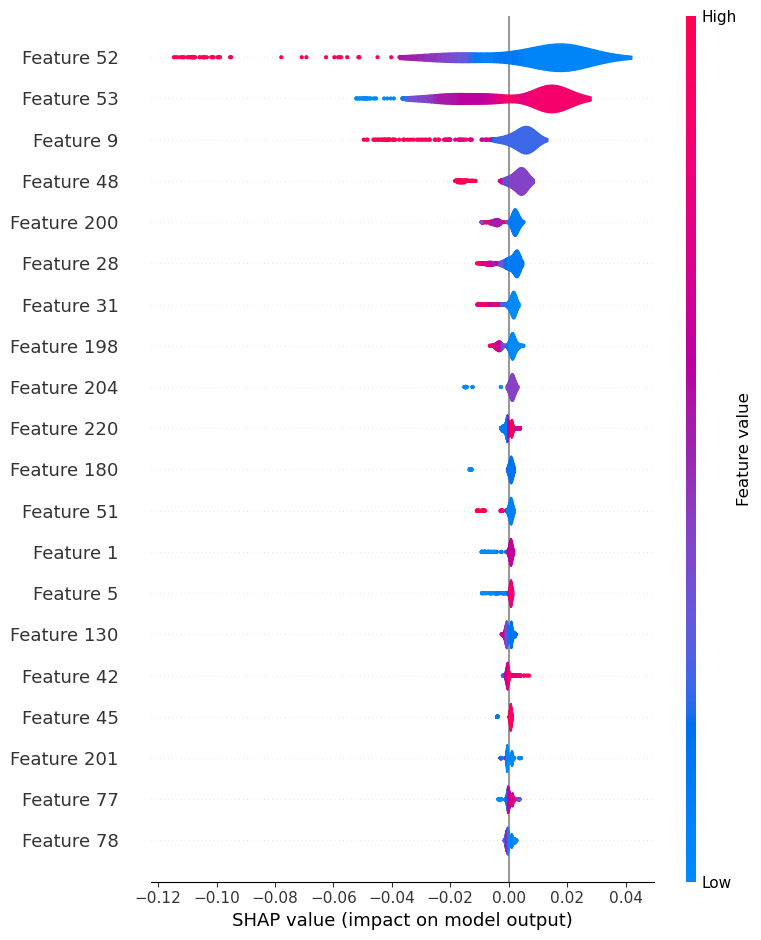

In [61]:
shap.summary_plot(shap_values_log, X_train_scaled, plot_type='violin')


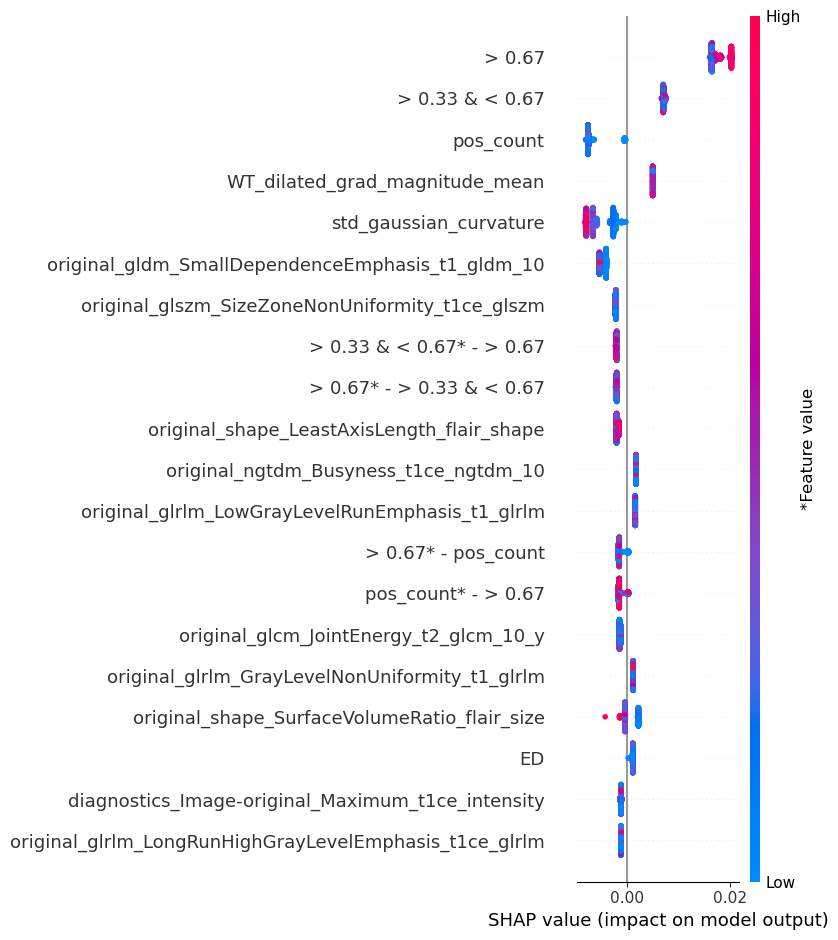

In [64]:
shap_interaction_values = shap.TreeExplainer(model).shap_interaction_values(X)
shap.summary_plot(shap_interaction_values, X, plot_type="compact_dot")

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# Define the hyperparameter space
space = {
    'n_estimators': hp.quniform('n_estimators', 10, 300, 1),
    'criterion': hp.choice('criterion', ['squared_error', 'absolute_error', 'friedman_mse', 'poisson']),
    'max_depth': hp.quniform('max_depth', 3, 30, 1),
    'min_samples_split': hp.quniform('min_samples_split', 2, 10, 1),
    'min_samples_leaf': hp.quniform('min_samples_leaf', 1, 5, 1),
    'min_weight_fraction_leaf': hp.uniform('min_weight_fraction_leaf', 0.0, 0.5),
    'max_features': hp.choice('max_features', [None, 'sqrt', 'log2']),
    'max_leaf_nodes': hp.quniform('max_leaf_nodes', 10, 1000, 1),
    'min_impurity_decrease': hp.uniform('min_impurity_decrease', 0.0, 0.1),
    'bootstrap': hp.choice('bootstrap', [True, False]),
    'ccp_alpha': hp.uniform('ccp_alpha', 0.0, 0.1),
    'max_samples': hp.quniform('max_samples', 0.1, 1.0, 0.05)
}

def objective(params, X_train, y_train):
    # Convert parameters to appropriate types
    params['n_estimators'] = int(params['n_estimators'])
    params['min_samples_split'] = int(params['min_samples_split'])
    params['min_samples_leaf'] = int(params['min_samples_leaf'])
    params['max_depth'] = int(params['max_depth']) # if params['max_depth'] is not None else None
    params['max_leaf_nodes'] = int(params['max_leaf_nodes']) if params['max_leaf_nodes'] is not None else None
#     params['criterion'] = ['squared_error', 'absolute_error', 'friedman_mse', 'poisson'][int(params['criterion'])]
#     params['max_features'] = [None, 'sqrt', 'log2'][int(params['max_features'])]
#     params['bootstrap'] = [True, False][int(params['bootstrap'])]
    
    # Set max_samples only if bootstrap is True
    if params['bootstrap']:
        params['max_samples'] = float(params['max_samples'])
    else:
        params['max_samples'] = None
#         params['oob_score'] = False

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    model = RandomForestRegressor(random_state=42, **params)

    mae = -cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='neg_mean_absolute_error').mean()
    return {'loss': mae, 'status': STATUS_OK}


# Outer K-Fold Cross-validation to evaluate the final model performance
kf_outer = KFold(n_splits=5, shuffle=True, random_state=42)
mse_scores, mae_scores, r2_scores = [], [], []

for train_index, test_index in kf_outer.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Run the hyperparameter optimization for each fold
    trials = Trials()
    # After calling fmin to get the best hyperparameters
    best = fmin(fn=lambda params: objective(params, X_train, y_train), space=space, algo=tpe.suggest, max_evals=100, trials=trials)
    print((best))
    # Map the indices to the actual values for categorical parameters
    best['criterion'] = ['squared_error', 'absolute_error', 'friedman_mse', 'poisson'][int(best['criterion'])]
    best['max_features'] = [None, 'sqrt', 'log2'][int(best['max_features'])]
    best['bootstrap'] = [True, False][int(best['bootstrap'])]
#     best['oob_score'] = [True, False][int(best['oob_score'])]

    # Ensure the rest of the parameters are of the correct type
    best['n_estimators'] = int(best['n_estimators'])
    best['max_depth'] = int(best['max_depth'])
    best['min_samples_split'] = int(best['min_samples_split'])
    best['min_samples_leaf'] = int(best['min_samples_leaf'])
    best['max_leaf_nodes'] = int(best['max_leaf_nodes'])# if best['max_leaf_nodes'] < 1000 else None  # Assuming 1000 is the upper limit used in space definition

    # max_samples needs special handling, as its value depends on the value of 'bootstrap'
    if best['bootstrap']:
        best['max_samples'] = float(best['max_samples'])
    else:
        best['max_samples'] = None


    # Train the final model on the training data with the best hyperparameters
    model = RandomForestRegressor(random_state=42, **best)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # Evaluate the model on the test set of the current fold
    mse_scores.append(mean_squared_error(y_test, y_pred))
    mae_scores.append(mean_absolute_error(y_test, y_pred))
    r2_scores.append(r2_score(y_test, y_pred))

# Average performance across all folds
print(f"Average MSE: {np.mean(mse_scores):.3f} ± {np.std(mse_scores):.3f}")
print(f"Average MAE: {np.mean(mae_scores):.3f} ± {np.std(mae_scores):.3f}")
print(f"Average R2: {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")
